In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from numpy import unique
from numpy import reshape
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from numpy import argmax
from PIL import Image
from numpy import asarray

In [4]:
tf.random.set_seed(42)

In [5]:
hand = mnist.load_data()

In [6]:
hand[0]

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [7]:
(X_train, y_train), (X_test, y_test) = hand

In [8]:
np.set_printoptions(edgeitems=3)
np.core.arrayprint._line_width = 180000

In [9]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [10]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [11]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

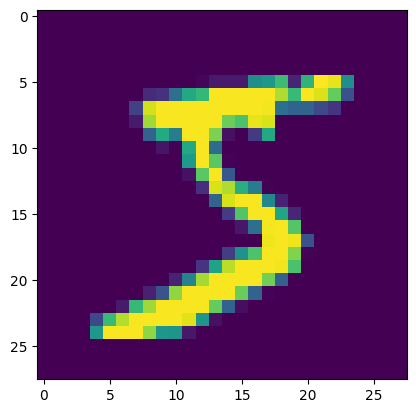

In [12]:
plt.imshow(X_train[0])

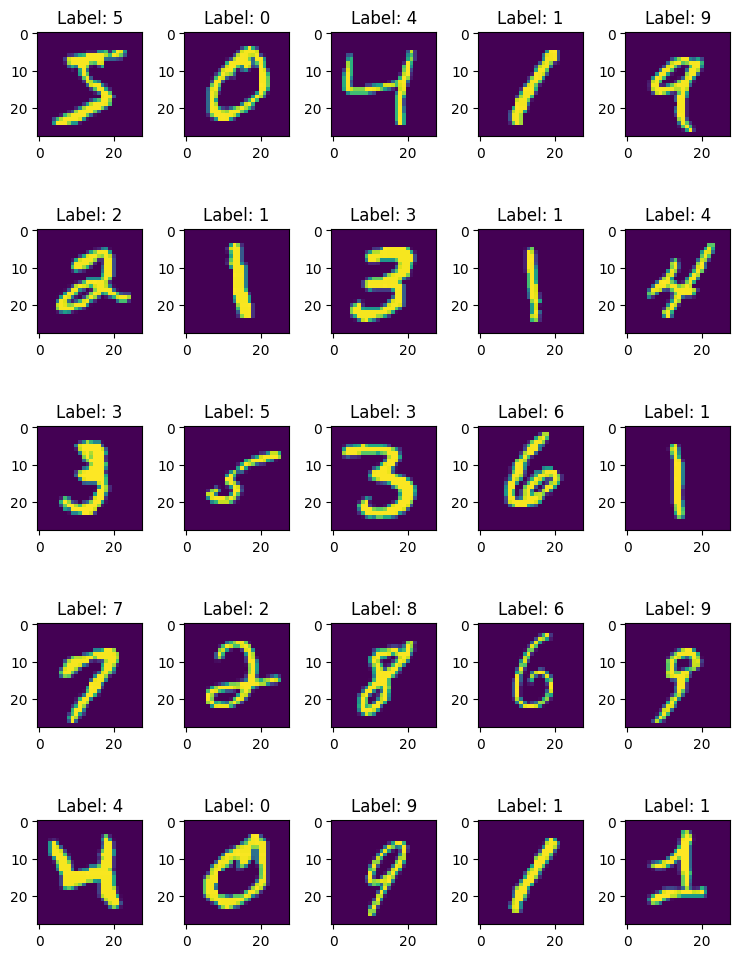

In [13]:
num = 25
images = X_train[:num]
labels = y_train[:num]

num_row = 5
num_col = 5
# plot images
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
    ax = axes[i//num_col, i%num_col]
    ax.imshow(images[i])#, cmap='gray')
    ax.set_title('Label: {}'.format(labels[i]))
plt.tight_layout()
plt.show()

In [14]:
# 5. Preprocess input data
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

In [15]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [16]:
X_train /= 255
X_test /= 255

In [17]:
# 6. Preprocess class labels
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

In [18]:
Y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [19]:
for label in range(10):
    one_hot = (Y_train[label]).astype(np.int32)
    print("label: ", label, " in one-hot representation: ", one_hot)

label:  0  in one-hot representation:  [0 0 0 0 0 1 0 0 0 0]
label:  1  in one-hot representation:  [1 0 0 0 0 0 0 0 0 0]
label:  2  in one-hot representation:  [0 0 0 0 1 0 0 0 0 0]
label:  3  in one-hot representation:  [0 1 0 0 0 0 0 0 0 0]
label:  4  in one-hot representation:  [0 0 0 0 0 0 0 0 0 1]
label:  5  in one-hot representation:  [0 0 1 0 0 0 0 0 0 0]
label:  6  in one-hot representation:  [0 1 0 0 0 0 0 0 0 0]
label:  7  in one-hot representation:  [0 0 0 1 0 0 0 0 0 0]
label:  8  in one-hot representation:  [0 1 0 0 0 0 0 0 0 0]
label:  9  in one-hot representation:  [0 0 0 0 1 0 0 0 0 0]


In [47]:
epochs = 30
batch_size = 16
n_hidden = 32

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [49]:
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("First label:", Y_train[0])

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)
First label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [51]:
tf.config.run_functions_eagerly(True)

In [53]:
# 9. Fit model on training data
model.fit(X_train, Y_train, batch_size=32, epochs=10, verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 385s 205ms/step - accuracy: 0.8689 - loss: 0.4116
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 444s 206ms/step - accuracy: 0.9742 - loss: 0.0892
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 387s 206ms/step - accuracy: 0.9798 - loss: 0.0671
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 447s 209ms/step - accuracy: 0.9829 - loss: 0.0563
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 454s 215ms/step - accuracy: 0.9858 - loss: 0.0455
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 432s 210ms/step - accuracy: 0.9875 - loss: 0.0414
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 449s 214ms/step - accuracy: 0.9888 - loss: 0.0362
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 443s 214ms/step - accuracy: 0.9892 - loss: 0.0344
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 443s 215ms/step - accuracy: 0.9910 - loss: 0.0300
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 443s 215ms/step - accuracy: 0.9908 - loss: 0.0288


In [55]:
# 10. Evaluate model on test data
score = model.evaluate(X_test, Y_test, verbose=2)

313/313 - 17s - 56ms/step - accuracy: 0.9927 - loss: 0.0277


In [57]:
#predict first 4 images in the test set
model.predict(X_test[:4])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


array([[3.0731162e-15, 3.8458170e-09, 1.6125161e-09, 3.6623971e-09,
        1.2912725e-12, 6.5531653e-14, 1.4589910e-18, 1.0000000e+00,
        5.2952293e-13, 5.5903471e-10],
       [2.3750140e-12, 6.7798887e-09, 1.0000000e+00, 2.0295871e-15,
        8.9576328e-13, 2.6377714e-19, 5.1227061e-10, 3.0383194e-13,
        4.6560978e-15, 2.2594043e-16],
       [5.5350832e-12, 9.9999964e-01, 2.0037534e-08, 4.3952116e-12,
        1.6633456e-07, 1.3232125e-09, 1.7307665e-08, 6.6461425e-08,
        8.2667277e-09, 8.5868528e-11],
       [9.9999905e-01, 1.1591678e-11, 3.7323491e-09, 1.1470981e-10,
        4.0136401e-12, 6.2052719e-10, 8.8851704e-07, 4.9213217e-08,
        6.8909460e-09, 3.4334221e-08]], dtype=float32)

In [59]:
sumarray = np.sum(model.predict(X_test[:4]), axis=1)
sumarray

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


array([1.       , 1.       , 0.9999999, 1.       ], dtype=float32)

In [61]:
#actual results for first 4 images in test set
y_test[:4]

array([7, 2, 1, 0], dtype=uint8)

In [63]:
test_predictions = model.predict(X_test)
cm = confusion_matrix(y_test, np.argmax(test_predictions,axis=1))
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step
[[ 976    0    1    0    0    0    1    0    1    1]
 [   0 1133    1    1    0    0    0    0    0    0]
 [   2    2 1025    0    0    0    0    3    0    0]
 [   0    0    1 1008    0    1    0    0    0    0]
 [   0    0    0    0  973    0    2    0    0    7]
 [   0    0    0    3    0  888    1    0    0    0]
 [   4    2    0    1    1    5  945    0    0    0]
 [   0    3    6    0    0    0    0 1018    1    0]
 [   1    0    2    3    0    0    0    1  965    2]
 [   0    0    1    2    3    3    0    2    2  996]]


In [64]:
path = 'C:/Users/andyc/Machine Learning - ClimateWins'
path

'C:/Users/andyc/Machine Learning - ClimateWins'

In [67]:
img = Image.open(os.path.join(path, 'Visualizations', 'Number Images', '0.jpg')) #<--FILL IN THIS VALUE!
print(img.format)
print(img.size)
print(img.mode)

JPEG
(3024, 4032)
L


In [69]:
# Define the list of numbers (0-9) for the labels
labels = list(range(10))

# Initialize lists to store the image data and labels
images = []
image_labels = []

# Loop through all numbers (0-9) and load corresponding images
for label in labels:
    # Open the image
    img_path = os.path.join(path, 'Visualizations', 'Number Images', f'{label}.jpg')
    img = Image.open(img_path)
    
    # Convert the image to grayscale (one single channel)
    img = img.convert('L')
    
    # Resize the image to 28x28
    newsize = (28, 28)
    img_resized = img.resize(newsize)
    
    # Convert the image to a numpy array
    img_array = np.asarray(img_resized)
    
    # Normalize the image data to the range [0, 1]
    img_array = img_array / 255.0
    
    # Reshape to match the CNN input format: (28, 28, 1)
    img_array = img_array.reshape(28, 28, 1)

    # Append the processed image and label to the respective lists
    images.append(img_array)
    image_labels.append(label)

# Convert the lists to numpy arrays
images = np.array(images)
image_labels = np.array(image_labels)

# One-hot encode the labels for CNN training
image_labels = to_categorical(image_labels, num_classes=10)

# Check the shapes of the images and labels
print("Images shape:", images.shape)  # Should be (10, 28, 28, 1) for 10 images
                                      # each resized to 28x28 and with 1 channel (grayscale)
print("Labels shape:", image_labels.shape)  # Should be (10, 10) for 10 images 
                                            #with 10 possible class labels (0-9)

Images shape: (10, 28, 28, 1)
Labels shape: (10, 10)


In [71]:
# Rename arrays

X_real_test = images  # Your preprocessed handwritten images
y_real_test = labels  # The true labels (0-9) for your handwritten images

In [73]:
# Run the model's predictions on the handwritten data
predictions = model.predict(X_real_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


C:\Users\andyc\anaconda3\envs\tf_env\lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


In [75]:
# Get the predicted class (the index of the maximum value in the output array)

predicted_labels = np.argmax(predictions, axis=1)

In [77]:
# Calculate accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_real_test, predicted_labels)
print(f"Model accuracy on handwritten data: {accuracy * 100:.2f}%")

Model accuracy on handwritten data: 20.00%


In [79]:
# Display the predicted and true labels

for i, (pred, actual) in enumerate(zip(predicted_labels, y_real_test)):
    print(f"Image {i}: Predicted = {pred}, Actual = {actual}")

Image 0: Predicted = 8, Actual = 0
Image 1: Predicted = 2, Actual = 1
Image 2: Predicted = 2, Actual = 2
Image 3: Predicted = 8, Actual = 3
Image 4: Predicted = 8, Actual = 4
Image 5: Predicted = 8, Actual = 5
Image 6: Predicted = 8, Actual = 6
Image 7: Predicted = 8, Actual = 7
Image 8: Predicted = 8, Actual = 8
Image 9: Predicted = 8, Actual = 9
